# AT3 — Explicabilidade local: regressão de chuva forte

O boosting quantílico salvo pelo `atv3_extremos` (o p90 da chuva, dado que o dia é forte: o valor que só 1 em cada 10 dias parecidos ultrapassa), explicada em quatro dias do teste com CP, ICE, LIME, SHAP e, como método adicional, contrafactuais com DiCE. A classificação é explicada à parte, nos mesmos quatro dias.

In [1]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", palette="deep", font_scale=1.4)
pd.set_option("display.width", 140)

In [2]:
# No Colab, descomente para montar o Drive:
# from google.colab import drive
#
# drive.mount('/content/drive')

In [3]:
from pathlib import Path

PASTA = Path("../../commons/data")
# No Colab, use o caminho do Drive:
# PASTA = Path("/content/drive/MyDrive")

df = pd.read_parquet(PASTA / "curitiba_daily.parquet").sort_values("date").reset_index(drop=True)

# synoptic.py e subdaily.py já deslocam para t-1: o join é sem shift
EXTRAS = []
for nome in ["curitiba_synoptic.parquet", "curitiba_subdaily.parquet"]:
    extra = pd.read_parquet(PASTA / nome)
    df = df.join(extra, on="date")
    EXTRAS += list(extra.columns)

# mesmas linhas dos notebooks dos modelos
df = df.dropna(subset=EXTRAS).reset_index(drop=True)
df.head()

,date,tp_mm,ssrd_wm2,t2m,t2m_min,t2m_max,d2m,dpd,wind_speed,wind_const,...,wind850_const,wind850_dir_sin,wind850_dir_cos,msl_tend,tcwv_tend,cape_tend,cape_max_lag3,tcwv_mean_lag3,wind_max,d2m_range
0,1980-04-01,0.365138,164.091782,16.377014,13.584625,19.219391,13.565399,2.811615,3.557601,0.994403,...,0.995480,0.867004,-0.498302,304.640625,-11.784046,-145.500,326.500,32.290985,4.239836,2.695099
1,1980-04-02,0.120771,179.277222,16.698456,13.498688,21.525055,13.814331,2.884125,2.316316,0.986427,...,0.964308,0.996868,-0.079082,-58.671875,-0.589602,-0.500,165.625,31.707979,3.681856,2.690460
2,1980-04-03,1.311496,195.243958,17.726776,14.785553,22.519684,14.285675,3.441101,1.947963,0.971664,...,0.901211,0.984846,0.173429,-131.968750,1.961582,-4.000,20.125,19.923933,2.749712,3.302399
3,1980-04-04,6.795540,148.697220,18.550293,15.958160,22.249176,16.062836,2.487457,1.714343,0.953920,...,0.983075,0.742985,0.669308,-87.796875,4.041027,-7.500,19.625,19.334332,2.709458,1.601349
4,1980-04-05,2.635221,144.128891,19.203552,17.001373,23.068512,17.138489,2.065063,1.144617,0.389403,...,0.197587,0.530985,-0.847381,-167.140625,10.413525,298.625,15.625,21.295914,1.956160,1.401917


In [4]:
FIGDIR = Path("figuras_explicabilidade")
FIGDIR.mkdir(exist_ok=True)

def salvar(nome, fig=None, dpi=200, fechar=False):
    """Salva a figura atual em PNG. Chame ANTES de plt.show()."""
    fig = fig or plt.gcf()
    fig.savefig(FIGDIR / f"{nome}.png", dpi=dpi,
                bbox_inches="tight", facecolor="white")
    print(f"salvo: {nome}.png")
    if fechar:
        plt.close(fig)

## 1. Problema, dados e modelo

In [5]:
reg = joblib.load("modelos/modelo_p90.joblib")
LIMIAR, ANO_CORTE, F, Q = reg["limiar"], reg["treino_ate"], reg["features"], reg["quantil"]
df["ano"] = df.date.dt.year
df["forte"] = (df.tp_mm >= LIMIAR).astype(int)

teste = df[(df.ano > ANO_CORTE) & (df.forte == 1)].reset_index(drop=True)   # só dias fortes
dev   = df[(df.ano <= ANO_CORTE) & (df.forte == 1)].reset_index(drop=True)  # treino do modelo

print(f"dados: ERA5-Land, Curitiba, {df.date.min():%Y-%m-%d} a {df.date.max():%Y-%m-%d}, {len(df)} dias")
print(f"treino: {len(dev)} dias fortes | teste: {len(teste)} dias fortes ({teste.ano.min()}–{teste.ano.max()})")

dados: ERA5-Land, Curitiba, 1980-04-01 a 2025-12-30, 16710 dias
treino: 1857 dias fortes | teste: 538 dias fortes (2015–2025)


In [6]:
from sklearn.metrics import mean_pinball_loss

modelo = reg["modelo"]
p_teste = modelo.predict(teste[F])
clim_teste = teste.date.dt.month.map(dev.groupby(dev.date.dt.month).tp_mm.quantile(Q)).to_numpy()
pin_mod, pin_clim = (mean_pinball_loss(teste.tp_mm, p, alpha=Q) for p in (p_teste, clim_teste))

print(f"{type(modelo).__name__}, quantil {Q}, {reg['hiperparametros']}")
print(f"pinball no teste: {pin_mod:.3f} (climatologia mensal {pin_clim:.3f}, ganho {100 * (1 - pin_mod / pin_clim):+.1f}%)")
print(f"cobertura: {100 * (teste.tp_mm <= p_teste).mean():.1f}% dos dias abaixo do teto (alvo {100 * Q:.0f}%)")
print("features:", F)

GradientBoostingRegressor, quantil 0.9, {'max_depth': 2, 'n_estimators': 100, 'min_samples_leaf': 20, 'learning_rate': 0.05, 'subsample': 0.8}
pinball no teste: 2.407 (climatologia mensal 2.486, ganho +3.2%)
cobertura: 90.5% dos dias abaixo do teto (alvo 90%)
features: ['ssrd_wm2', 't2m', 'd2m', 'dpd', 'wind_speed', 'wind_const', 'wind_dir_sin', 'wind_dir_cos', 'day_sin', 'day_cos', 'tp_lag1']


## 2. Observações de interesse

A saída é um teto por dia: a chuva fica abaixo dele em 90% dos dias fortes com uma véspera parecida. Os quatro dias do teste
são escolhidos por regras que usam só esse teto. A classificação explica os mesmos quatro dias.

- **passou do teto**: o maior excesso da chuva sobre o teto, o evento que o modelo não viu chegando
- **teto alto**: a maior previsão, o dia em que o modelo vê mais potencial
- **dia calmo**: a menor previsão
- **dia típico**: teto perto da mediana dos tetos e chuva perto da mediana observada

In [7]:
obs = teste[["date", "tp_mm"] + F].copy()
obs["pred_p90"] = p_teste
obs["excesso"] = obs.tp_mm - obs.pred_p90          # > 0: a chuva passou do teto

perto_mediana = obs[(obs.pred_p90 - obs.pred_p90.median()).abs() <= 1]

REGRAS = {
    # o evento que passou mais longe do teto
    "passou do teto": obs.excesso.idxmax(),
    # a maior previsão: o dia em que o modelo vê mais potencial
    "teto alto":      obs.pred_p90.idxmax(),
    # a menor previsão
    "dia calmo":      obs.pred_p90.idxmin(),
    # teto perto da mediana dos tetos e chuva perto da mediana observada
    "dia típico":     (perto_mediana.tp_mm - obs.tp_mm.median()).abs().idxmin(),
}
assert len(set(REGRAS.values())) == len(REGRAS), "duas regras escolheram o mesmo dia"
escolhidos = obs.loc[list(REGRAS.values())].assign(papel=list(REGRAS.keys())).set_index("papel")
print(f"teto mediano {obs.pred_p90.median():.2f} mm ({len(perto_mediana)} dias a até 1 mm dele) | "
      f"chuva mediana {obs.tp_mm.median():.2f} mm\n")
print(escolhidos[["date", "tp_mm", "pred_p90", "excesso"]].round(2).to_string())
print()
print(escolhidos[F].round(2).T.to_string())

teto mediano 27.88 mm (71 dias a até 1 mm dele) | chuva mediana 15.97 mm

                     date      tp_mm  pred_p90  excesso
papel                                                  
passou do teto 2024-11-07  79.910004     24.14    55.76
teto alto      2017-06-06  20.150000     54.00   -33.85
dia calmo      2018-03-06  11.770000     18.27    -6.50
dia típico     2019-04-07  16.000000     27.06   -11.06

papel         passou do teto  teto alto   dia calmo  dia típico
ssrd_wm2          180.399994  47.419998  224.570007   66.010002
t2m                19.969999  17.690001   21.610001   19.379999
d2m                18.280001  16.450001   18.879999   18.260000
dpd                 1.690000   1.250000    2.730000    1.120000
wind_speed          2.180000   3.650000    1.500000    2.580000
wind_const          0.920000   0.960000    0.350000    0.980000
wind_dir_sin        0.990000  -0.640000   -1.000000    1.000000
wind_dir_cos        0.110000   0.770000    0.060000    0.030000
day_sin      

salvo: observacoes.png


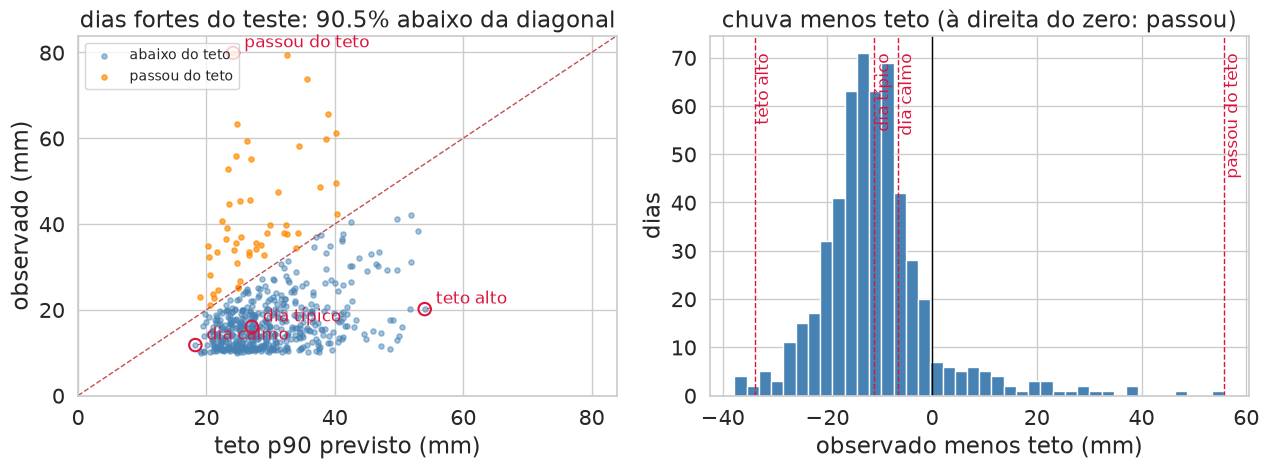

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = [0, obs.tp_mm.max() * 1.05]
abaixo = obs.excesso <= 0
axes[0].scatter(obs.pred_p90[abaixo], obs.tp_mm[abaixo], s=14, alpha=.5, color="steelblue", label="abaixo do teto")
axes[0].scatter(obs.pred_p90[~abaixo], obs.tp_mm[~abaixo], s=14, alpha=.7, color="darkorange", label="passou do teto")
axes[0].plot(lim, lim, "r--", lw=1)
for papel, r in escolhidos.iterrows():
    axes[0].annotate(papel, (r.pred_p90, r.tp_mm), fontsize=12, color="crimson",
                     xytext=(8, 4), textcoords="offset points",
                     arrowprops={"arrowstyle": "-", "color": "crimson", "lw": .6})
    axes[0].scatter(r.pred_p90, r.tp_mm, s=80, facecolors="none", edgecolors="crimson", lw=1.5)
axes[0].set(title=f"dias fortes do teste: {100 * abaixo.mean():.1f}% abaixo da diagonal",
            xlabel="teto p90 previsto (mm)", ylabel="observado (mm)", xlim=lim, ylim=lim)
axes[0].legend(loc="upper left", fontsize=10)

axes[1].hist(obs.excesso, bins=40, color="steelblue")
axes[1].axvline(0, color="black", lw=1)
for papel, r in escolhidos.iterrows():
    axes[1].axvline(r.excesso, color="crimson", ls="--", lw=1)
    axes[1].text(r.excesso, axes[1].get_ylim()[1] * .95, f" {papel}", rotation=90,
                 va="top", fontsize=12, color="crimson")
axes[1].set(title="chuva menos teto (à direita do zero: passou)", xlabel="observado menos teto (mm)", ylabel="dias")

plt.tight_layout()
salvar("observacoes")
plt.show()

salvo: teto_por_arvore.png


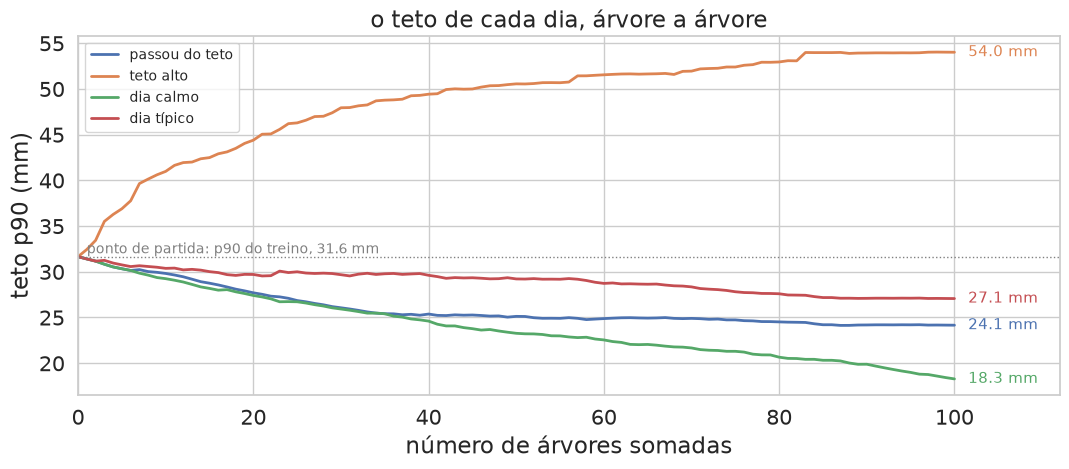

In [9]:
# como o teto de cada dia é construído: começa no p90 de todos os dias fortes do treino
# e cada árvore soma uma pequena correção (taxa de aprendizado 0,05)
cores = dict(zip(escolhidos.index, sns.color_palette("deep", len(escolhidos))))
etapas = np.array(list(modelo.staged_predict(escolhidos[F])))      # árvore × dia
inicio = float(modelo.init_.predict(escolhidos[F].iloc[:1])[0])

fig, ax = plt.subplots(figsize=(11, 5))
n = np.arange(0, len(etapas) + 1)
for k, papel in enumerate(escolhidos.index):
    ax.plot(n, np.r_[inicio, etapas[:, k]], color=cores[papel], lw=2, label=papel)
    ax.text(n[-1] + 1, etapas[-1, k], f" {etapas[-1, k]:.1f} mm", va="center", fontsize=11, color=cores[papel])
ax.axhline(inicio, color="gray", ls=":", lw=1)
ax.text(1, inicio, f"ponto de partida: p90 do treino, {inicio:.1f} mm", va="bottom", fontsize=10, color="gray")
ax.set(title="o teto de cada dia, árvore a árvore", xlabel="número de árvores somadas", ylabel="teto p90 (mm)",
       xlim=(0, n[-1] + 12))
ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
salvar("teto_por_arvore")
plt.show()

## 3. CP Plot e ICE

**CP** (*ceteris paribus*): para um dia, varia uma feature e mantém as outras fixas. **ICE**: o CP de todos os dias fortes do teste; a média das curvas é o PDP.

In [10]:
import warnings
import dalex as dx
from sklearn.inspection import partial_dependence

warnings.filterwarnings("ignore", message="Parameter `variable_splits`")

# importância por impureza, somada nas árvores do boosting
imp = pd.Series(modelo.feature_importances_, index=F).sort_values(ascending=False)
print(imp.round(3).to_string())

FEATS_CP = imp.index[:6].tolist()                    # as 6 mais usadas pelo modelo (a grade é 2 × 3)
print("\nfeatures dos gráficos:", FEATS_CP)

# grade: 101 quantis de cada feature nos dias fortes do teste
GRADE_CP = {f: np.unique(np.quantile(teste[f], np.linspace(0, 1, 101))) for f in F}

wind_speed      0.185
day_cos         0.138
wind_dir_sin    0.129
wind_dir_cos    0.122
ssrd_wm2        0.105
tp_lag1         0.103
day_sin         0.062
dpd             0.059
d2m             0.040
wind_const      0.039
t2m             0.018

features dos gráficos: ['wind_speed', 'day_cos', 'wind_dir_sin', 'wind_dir_cos', 'ssrd_wm2', 'tp_lag1']


In [11]:
exp_reg = dx.Explainer(modelo, teste[F], teste.tp_mm, label="p90", verbose=False)
cp = exp_reg.predict_profile(escolhidos[F], variable_splits=GRADE_CP, verbose=False).result

# amplitude do CP: quanto o teto do dia pode mudar mexendo só nesta feature
amp_cp = cp.groupby(["_vname_", "_ids_"])._yhat_.agg(lambda s: s.max() - s.min()).unstack()[escolhidos.index]
amp_cp.index.name = None
print(amp_cp.round(2).to_string())

_ids_         passou do teto  teto alto  dia calmo  dia típico
d2m                     0.83       2.86       0.68        1.33
day_cos                 5.92       9.09       8.73        5.81
day_sin                 4.63       1.46       3.97        2.50
dpd                    11.26       3.97      11.40       10.79
ssrd_wm2                4.33       2.96       7.23        4.45
t2m                     0.46       0.90       0.30        0.46
tp_lag1                 8.21       3.16       6.46        6.66
wind_const              0.54       3.89       1.11        0.69
wind_dir_cos            3.06       9.15       1.70        3.25
wind_dir_sin            2.94       7.18       2.55        5.77
wind_speed             15.08      19.76      15.61        9.49


In [12]:
# o CP muda uma variável e congela as outras, então visita combinações que não existem.
# Quanto da grade é impossível para o dia de teto alto?
d = escolhidos.loc["teto alto"]
mes = d.date.month
max_mes = df[df.date.dt.month == mes].ssrd_wm2.max()
cos_ok = np.sqrt(1 - d.wind_dir_sin ** 2)
print(f"orvalho acima da temperatura do dia ({d.t2m:.1f} °C): "
      f"{100 * (GRADE_CP['d2m'] > d.t2m).mean():.0f}% da grade de d2m")
print(f"cosseno fora do círculo (seno fixo em {d.wind_dir_sin:.2f}, cosseno possível ±{cos_ok:.2f}): "
      f"{100 * (np.abs(np.abs(GRADE_CP['wind_dir_cos']) - cos_ok) > 0.05).mean():.0f}% da grade")
print(f"radiação: grade vai até {GRADE_CP['ssrd_wm2'].max():.0f} W/m², máximo já registrado no mês {mes}: {max_mes:.0f} W/m²")

orvalho acima da temperatura do dia (17.7 °C): 40% da grade de d2m
cosseno fora do círculo (seno fixo em -0.64, cosseno possível ±0.77): 90% da grade
radiação: grade vai até 354 W/m², máximo já registrado no mês 6: 189 W/m²


salvo: cp_plot.png


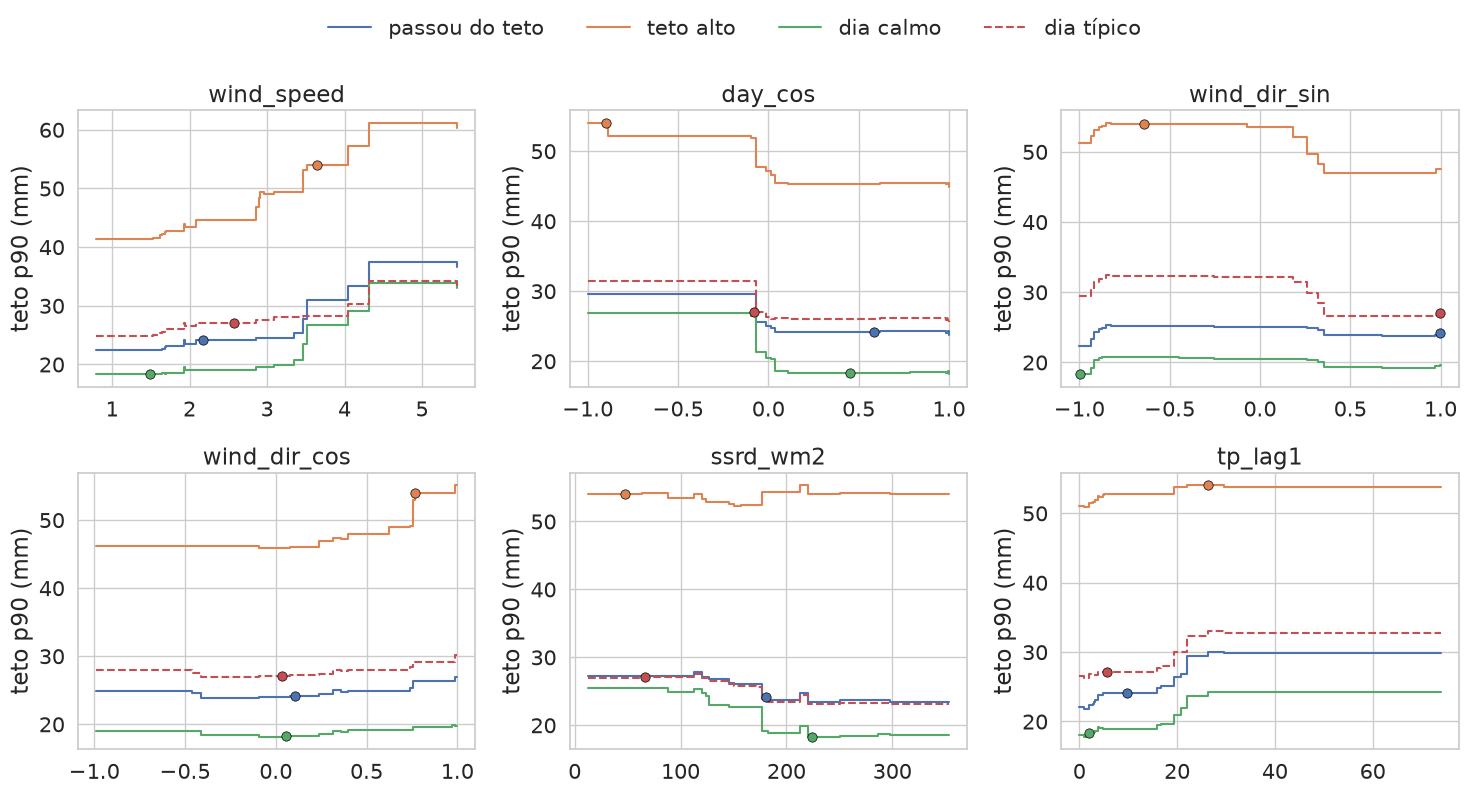

In [13]:
cores = dict(zip(escolhidos.index, sns.color_palette("deep", len(escolhidos))))
# tracejado para o dia típico não esconder curvas sobrepostas
traco = {"dia típico": "--"}

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, f in zip(axes.flat, FEATS_CP):
    for papel in escolhidos.index:
        g = cp[(cp._vname_ == f) & (cp._ids_ == papel)]
        ax.step(g[f], g._yhat_, where="post", color=cores[papel], lw=1.5, ls=traco.get(papel, "-"), label=papel)
        ax.scatter(escolhidos.loc[papel, f], escolhidos.loc[papel, "pred_p90"],
                   color=cores[papel], s=45, zorder=5, edgecolor="black", lw=.5)
    ax.set(title=f, xlabel="", ylabel="teto p90 (mm)")
plt.tight_layout()
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="lower center",
           bbox_to_anchor=(.5, 1.0), ncol=len(escolhidos), frameon=False)
salvar("cp_plot")
plt.show()

In [14]:
ice = {}
for f in F:
    pdr = partial_dependence(modelo, teste[F], [f], kind="both", custom_values={f: GRADE_CP[f]})
    ice[f] = (pdr["grid_values"][0], pdr["individual"][0], pdr["average"][0])

# PDP mede o efeito médio; amplitude média das curvas individuais mede o efeito dia a dia.
# Curvas individuais muito diferentes do PDP = a feature interage com as outras.
het = pd.DataFrame([
    {"feature": f, "amp_PDP": avg.max() - avg.min(),
     "amp_ICE_media": (ind.max(axis=1) - ind.min(axis=1)).mean(),
     "pct_curvas_planas": 100 * ((ind.max(axis=1) - ind.min(axis=1)) < 1e-9).mean()}
    for f, (_, ind, avg) in ice.items()]).set_index("feature")
print(het.round(2).to_string())

              amp_PDP  amp_ICE_media  pct_curvas_planas
feature                                                
ssrd_wm2         4.91           5.38                0.0
t2m              0.45           0.52                0.0
d2m              1.28           1.41                0.0
dpd              9.01           9.01                0.0
wind_speed      16.21          16.23                0.0
wind_const       2.33           2.44                0.0
wind_dir_sin     3.74           4.24                0.0
wind_dir_cos     4.41           4.52                0.0
day_sin          3.15           3.16                0.0
day_cos          6.48           6.54                0.0
tp_lag1          6.10           6.10                0.0


salvo: ice.png


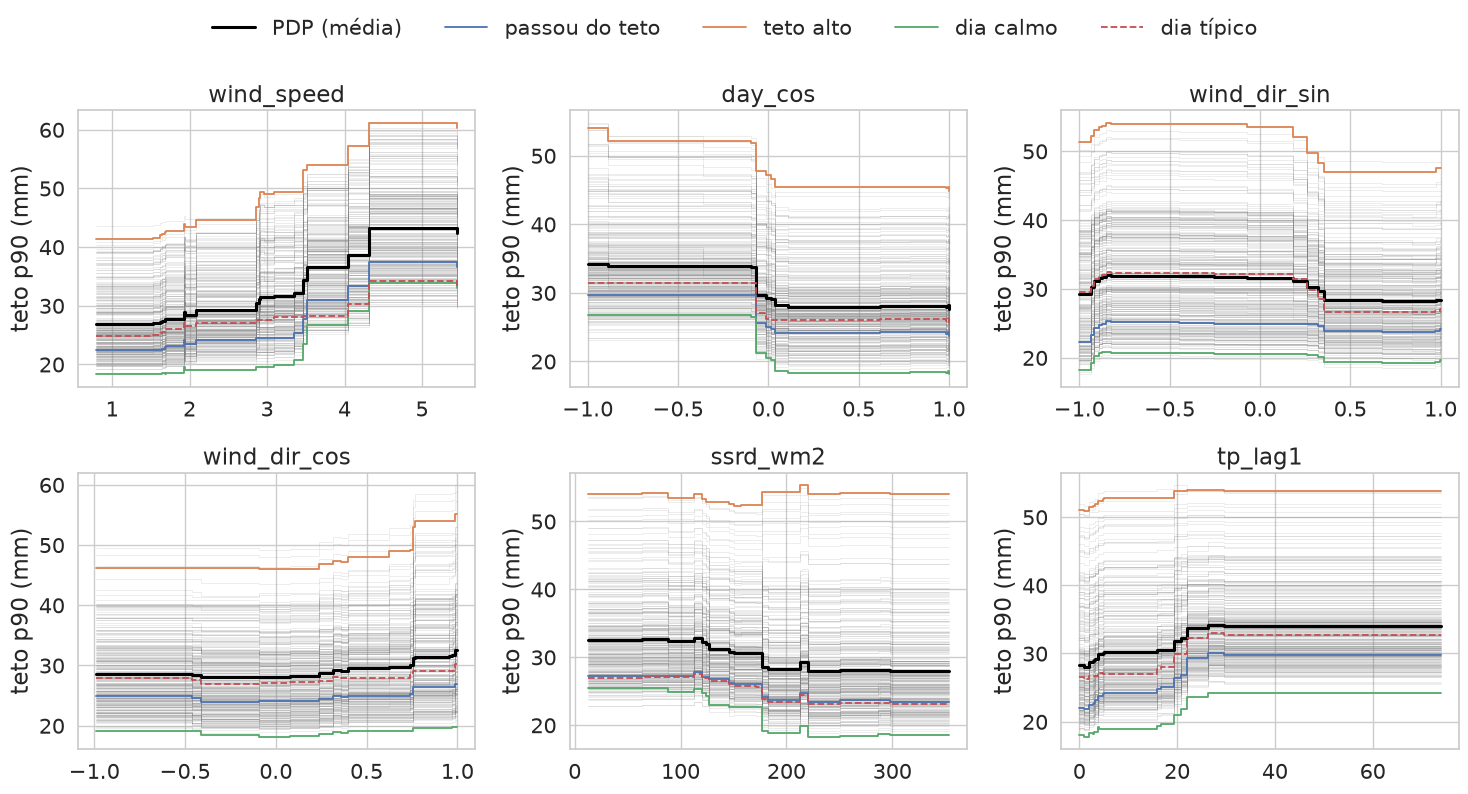

In [15]:
rng = np.random.default_rng(42)

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, f in zip(axes.flat, FEATS_CP):
    grade, ind, avg = ice[f]
    for k in rng.choice(len(ind), size=min(300, len(ind)), replace=False):
        ax.step(grade, ind[k], where="post", color="gray", lw=.4, alpha=.25)
    ax.step(grade, avg, where="post", color="black", lw=2.2, label="PDP (média)")
    for papel in escolhidos.index:
        g = cp[(cp._vname_ == f) & (cp._ids_ == papel)]
        ax.step(g[f], g._yhat_, where="post", color=cores[papel], lw=1.3, ls=traco.get(papel, "-"), label=papel)
    ax.set(title=f, xlabel="", ylabel="teto p90 (mm)")
plt.tight_layout()
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="lower center",
           bbox_to_anchor=(.5, 1.0), ncol=5, frameon=False)
salvar("ice")
plt.show()

## 4. LIME

Sorteia vizinhos a partir do treino, pergunta ao modelo a previsão de cada um e ajusta uma regressão linear ponderada pela distância. Os pesos dessa reta são a explicação.

In [16]:
from lime.lime_tabular import LimeTabularExplainer

# parâmetros padrão: quartis do treino, 5.000 vizinhos, núcleo de largura 0,75·√12, Ridge
lime_exp = LimeTabularExplainer(dev[F].values, feature_names=F, mode="regression", random_state=42)
prever = lambda X: modelo.predict(pd.DataFrame(X, columns=F))

def explicar_lime(papel, seed=42):
    lime_exp.random_state = np.random.RandomState(seed)
    e = lime_exp.explain_instance(escolhidos.loc[papel, F].values.astype(float), prever,
                                  num_features=len(F), num_samples=5000)
    return dict(e.as_list()), e.score, e.local_pred[0]

lime_res, lime_fid = {}, []
for papel in escolhidos.index:
    pesos, r2, local = explicar_lime(papel)
    lime_res[papel] = pesos
    lime_fid.append({"papel": papel, "previsão_modelo": escolhidos.loc[papel, "pred_p90"],
                     "previsão_LIME": local, "R2_local": r2})
print(pd.DataFrame(lime_fid).set_index("papel").round(3).to_string())

                previsão_modelo  previsão_LIME  R2_local
papel                                                   
passou do teto           24.144         23.022     0.129
teto alto                53.998         49.001     0.529
dia calmo                18.268         22.966     0.213
dia típico               27.056         28.086     0.141


salvo: lime.png


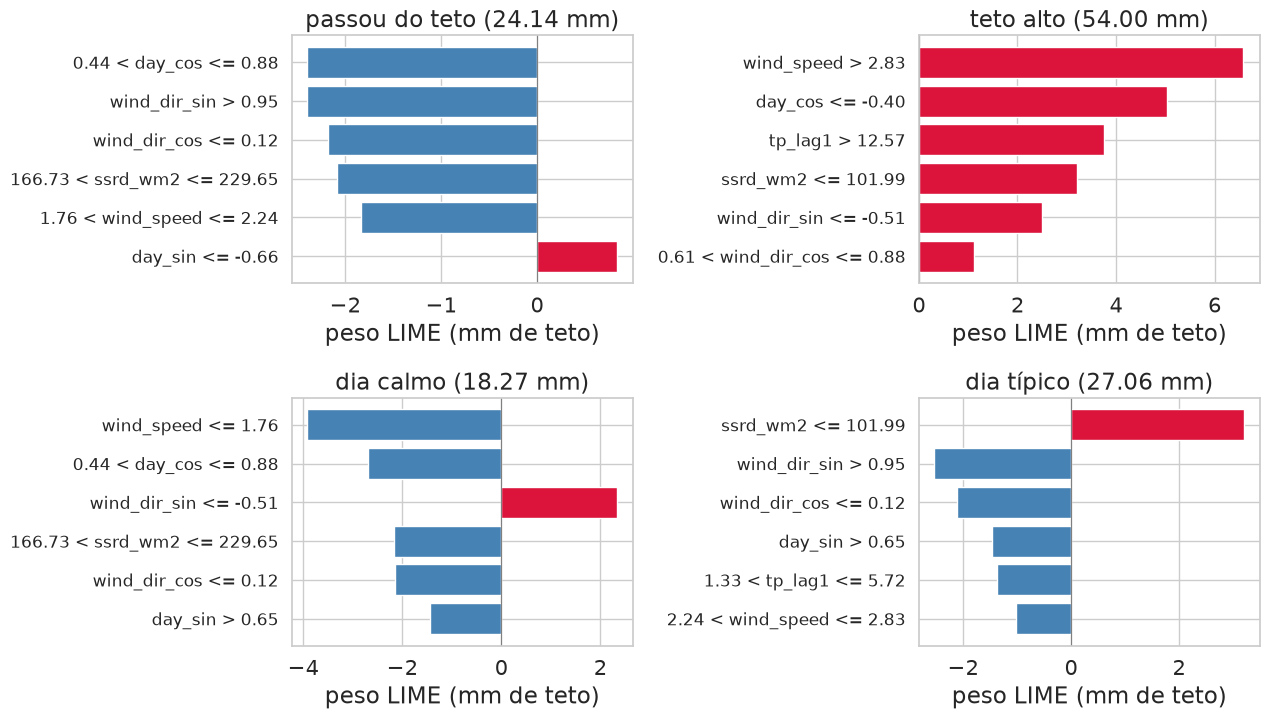

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
for ax, papel in zip(axes.flat, escolhidos.index):
    w = pd.Series(lime_res[papel]).sort_values(key=abs).tail(6)
    ax.barh(w.index, w.values, color=["crimson" if v > 0 else "steelblue" for v in w.values])
    ax.axvline(0, color="gray", lw=.8)
    ax.tick_params(axis="y", labelsize=12)
    ax.set(title=f"{papel} ({escolhidos.loc[papel, 'pred_p90']:.2f} mm)", xlabel="peso LIME (mm de teto)")
plt.tight_layout()
salvar("lime")
plt.show()

In [18]:
# estabilidade: o LIME sorteia vizinhos, então sementes diferentes dão explicações diferentes
def feat_de(chave):
    return next(f for f in sorted(F, key=len, reverse=True) if f in chave)

estab = []
for papel in escolhidos.index:
    tops = []
    for seed in range(10):
        pesos, _, _ = explicar_lime(papel, seed=seed)
        por_feat = pd.Series({feat_de(k): abs(v) for k, v in pesos.items()})
        tops.append(tuple(sorted(por_feat.nlargest(3).index)))
    mais_comum = pd.Series(tops).value_counts()
    estab.append({"papel": papel, "top3_mais_comum": mais_comum.index[0],
                  "pct_sementes": 10 * mais_comum.iloc[0]})
print(pd.DataFrame(estab).set_index("papel").to_string())
menos_usada = imp.idxmin()
print(f"\npeso do LIME em {menos_usada}, a feature menos usada pelo modelo:",
      {p: [round(v, 3) for k, v in lime_res[p].items() if feat_de(k) == menos_usada] for p in escolhidos.index})

                                       top3_mais_comum  pct_sementes
papel                                                               
passou do teto   (day_cos, wind_dir_cos, wind_dir_sin)            40
teto alto               (day_cos, tp_lag1, wind_speed)           100
dia calmo          (day_cos, wind_dir_cos, wind_speed)            70
dia típico      (ssrd_wm2, wind_dir_cos, wind_dir_sin)           100

peso do LIME em t2m, a feature menos usada pelo modelo: {'passou do teto': [0.002], 'teto alto': [0.066], 'dia calmo': [0.367], 'dia típico': [-0.219]}


## 5. SHAP

Divide a diferença entre a previsão do dia e a previsão média entre as features (valores de Shapley). O TreeSHAP é exato para árvores e para somas de árvores, como o boosting. Aqui cada valor diz quantos mm a feature subiu ou baixou o teto do dia.

In [19]:
warnings.filterwarnings("ignore", message="IProgress not found")
import shap

tree_exp = shap.TreeExplainer(modelo)
shap_res = pd.DataFrame(tree_exp.shap_values(escolhidos[F]), index=escolhidos.index, columns=F)
base = float(np.ravel(tree_exp.expected_value)[0])

# aditividade: base + soma dos SHAP = previsão do modelo
assert np.allclose(base + shap_res.sum(axis=1), escolhidos.pred_p90)
print(f"valor base {base:.3f} mm (o teto médio) | base + soma = teto do dia em todos os dias\n")
print(shap_res.T.round(3).to_string())

valor base 29.906 mm (o teto médio) | base + soma = teto do dia em todos os dias

papel         passou do teto  teto alto  dia calmo  dia típico
ssrd_wm2              -1.393      1.382     -2.755       2.195
t2m                    0.018      0.008     -0.012      -0.020
d2m                   -0.007      1.089      0.027       0.259
dpd                   -0.384     -0.172     -0.235       0.059
wind_speed            -0.241      7.813     -1.936      -0.129
wind_const            -0.075      0.422      0.192       0.144
wind_dir_sin          -0.929      2.933     -1.219      -1.820
wind_dir_cos          -1.261      2.746     -1.116      -1.361
day_sin                0.188      0.162     -1.137      -1.476
day_cos               -1.912      4.772     -2.471      -0.628
tp_lag1                0.232      2.937     -0.975      -0.073


salvo: shap.png


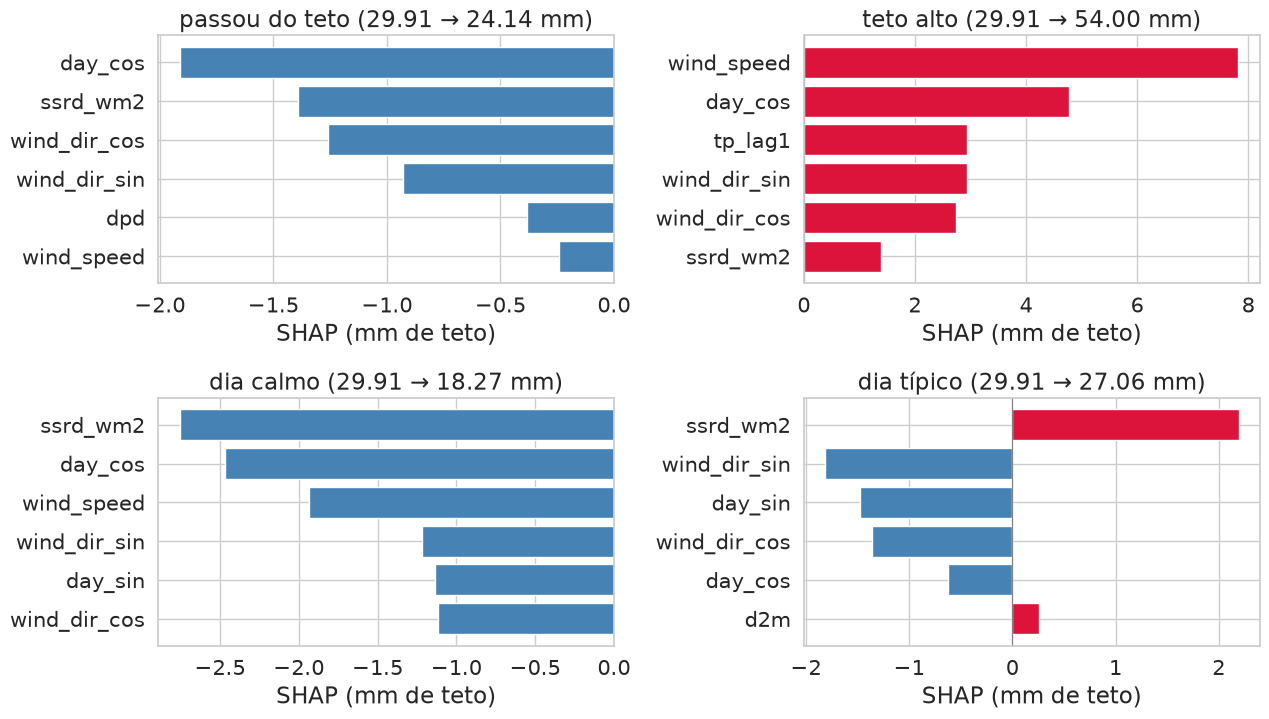

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
for ax, papel in zip(axes.flat, escolhidos.index):
    s = shap_res.loc[papel].sort_values(key=abs).tail(6)
    ax.barh(s.index, s.values, color=["crimson" if v > 0 else "steelblue" for v in s.values])
    ax.axvline(0, color="gray", lw=.8)
    ax.set(title=f"{papel} ({base:.2f} → {escolhidos.loc[papel, 'pred_p90']:.2f} mm)", xlabel="SHAP (mm de teto)")
plt.tight_layout()
salvar("shap")
plt.show()

## 6. Método adicional: contrafactuais com DiCE

Que mudança mínima na véspera levaria o teto do dia para outra faixa (Mothilal et al., 2020)? Busca aleatória, com o dia do ano fixo. Para os dias com teto abaixo de 35 mm, a faixa-alvo é de 40 a 50 mm, um dia de risco. Para o teto alto, é de 18 a 25 mm, um dia calmo. Cada contrafactual é conferido no modelo, e os fisicamente impossíveis são marcados: orvalho acima da temperatura, `dpd` diferente de `t2m − d2m`, seno e cosseno fora do círculo, ou radiação acima do máximo já registrado no mês do dia.

In [21]:
import dice_ml
from raiutils.exceptions import UserConfigValidationException   # a que o DiCE lança

dice_dados = dice_ml.Data(dataframe=dev[F + ["tp_mm"]].astype(float), continuous_features=F,
                          outcome_name="tp_mm")
dice_exp = dice_ml.Dice(dice_dados, dice_ml.Model(model=modelo, backend="sklearn", model_type="regressor"),
                        method="random")
VARIA = [f for f in F if f not in ("day_sin", "day_cos")]          # a data não muda
MAX_MES = df.groupby(df.date.dt.month).ssrd_wm2.max()

def impossivel(cf, mes):
    return bool(cf.d2m > cf.t2m or abs(cf.dpd - (cf.t2m - cf.d2m)) > 0.5
                or abs(cf.wind_dir_sin ** 2 + cf.wind_dir_cos ** 2 - 1) > 0.1
                or cf.ssrd_wm2 > MAX_MES[mes])

cfs, sem_cf = [], []
for papel in escolhidos.index:
    q = escolhidos.loc[[papel], F].astype(float)
    p0 = escolhidos.loc[papel, "pred_p90"]
    faixa = [18.0, 25.0] if p0 >= 35 else [40.0, 50.0]
    try:
        r = dice_exp.generate_counterfactuals(q, total_CFs=20, desired_range=faixa, features_to_vary=VARIA,
                                              random_seed=42, verbose=False)
        final = r.cf_examples_list[0].final_cfs_df
    except UserConfigValidationException:          # o DiCE lança exceção quando não acha nenhum
        final = None
    if final is None:
        sem_cf.append(f"{papel} ({faixa[0]:g} a {faixa[1]:g} mm)")
        continue
    for _, cf in final[F].astype(float).iterrows():
        p1 = modelo.predict(cf.to_frame().T)[0]
        if not faixa[0] <= p1 <= faixa[1]:
            continue                                     # não chegou à faixa de verdade
        mud = {f: (round(q.iloc[0][f], 2), round(cf[f], 2)) for f in F if abs(cf[f] - q.iloc[0][f]) > 1e-6}
        cfs.append({"papel": papel, "faixa": f"{faixa[0]:g} a {faixa[1]:g} mm", "antes": round(p0, 2),
                    "depois": round(p1, 2), "n_mudanças": len(mud),
                    "impossível": impossivel(cf, escolhidos.loc[papel, "date"].month),
                    "mudanças (de, para)": mud})

cfs = pd.DataFrame(cfs).sort_values(["papel", "impossível", "n_mudanças"])
with pd.option_context("display.max_colwidth", 250):
    print(cfs.groupby("papel", sort=False).head(4).to_string(index=False))
print()
print(cfs.groupby("papel", sort=False).agg(contrafactuais=("n_mudanças", "size"),
                                           impossíveis=("impossível", "sum"),
                                           mínimo_de_mudanças=("n_mudanças", "min")).to_string())
print("\nsem contrafactual na busca:", sem_cf or "nenhum")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  9.80it/s]

100%|██████████| 1/1 [00:00<00:00,  9.76it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  9.22it/s]

...

100%|██████████| 1/1 [00:00<00:00,  8.96it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  9.15it/s]

100%|██████████| 1/1 [00:00<00:00,  9.11it/s]

         papel      faixa  antes  depois  n_mudanças  impossível                                                                                        mudanças (de, para)
     dia calmo 40 a 50 mm  18.27   41.76           2        True                                                  {'wind_speed': (1.5, 5.85), 'wind_dir_cos': (0.06, 0.88)}
     dia calmo 40 a 50 mm  18.27   41.76           2        True                                                  {'wind_speed': (1.5, 5.62), 'wind_dir_cos': (0.06, 0.79)}
     dia calmo 40 a 50 mm  18.27   41.76           2        True                                                  {'wind_speed': (1.5, 5.67), 'wind_dir_cos': (0.06, 0.81)}
     dia calmo 40 a 50 mm  18.27   41.76           2        True                                                  {'wind_speed': (1.5, 5.73), 'wind_dir_cos': (0.06, 0.83)}
    dia típico 40 a 50 mm  27.06   40.09           3       False                        {'ssrd_wm2': (66.01, 233.23), 'wind_speed': (2.58, 4

## Comparação entre os métodos

In [22]:
from scipy.stats import spearmanr

comp = []
for papel in escolhidos.index:
    lime_abs = pd.Series({feat_de(k): abs(v) for k, v in lime_res[papel].items()}).reindex(F)
    shap_abs = shap_res.loc[papel].abs()
    cp_amp   = amp_cp[papel].reindex(F)
    comp.append({
        "papel": papel,
        "top3_CP":   ", ".join(cp_amp[cp_amp > 1e-9].nlargest(3).index),   # só as que mexem
        "top3_LIME": ", ".join(lime_abs.nlargest(3).index),
        "top3_SHAP": ", ".join(shap_abs[shap_abs > 1e-9].nlargest(3).index),
        "spearman_LIME_SHAP": spearmanr(lime_abs, shap_abs).statistic,
        "SHAP_zero": int((shap_abs < 1e-9).sum()),
    })
comp = pd.DataFrame(comp).set_index("papel")
print(comp.round(2).to_string())

                                          top3_CP                             top3_LIME                        top3_SHAP  spearman_LIME_SHAP  SHAP_zero
papel                                                                                                                                                  
passou do teto           wind_speed, dpd, tp_lag1   day_cos, wind_dir_sin, wind_dir_cos  day_cos, ssrd_wm2, wind_dir_cos                0.89          0
teto alto       wind_speed, wind_dir_cos, day_cos          wind_speed, day_cos, tp_lag1     wind_speed, day_cos, tp_lag1                0.90          0
dia calmo                wind_speed, dpd, day_cos     wind_speed, day_cos, wind_dir_sin    ssrd_wm2, day_cos, wind_speed                0.85          0
dia típico               dpd, wind_speed, tp_lag1  ssrd_wm2, wind_dir_sin, wind_dir_cos  ssrd_wm2, wind_dir_sin, day_sin                0.65          0
